<a href="https://colab.research.google.com/github/ibtihalalf/Sdaia-Bootcamp/blob/main/Week5/M6/ex1_pycaret_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M4.Ex1: Housing Prices Model (PyCaret)

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M6/exercises/ex1_pycaret_regression.ipynb)

## Exercise

Your task is to follow the steps outlined here, and apply them on the **California Housing Dataset** below:

- [**🚀 Regression**](https://pycaret.gitbook.io/docs/get-started/quickstart#regression)
    - Setup
    - Compare Models
    - Analyze Model
    - Predictions
    - Save the model

## California Housing Prices Dataset


Find and download the dataset from Kaggle at [California Housing Dataset](https://www.kaggle.com/datasets/dhirajnirne/california-housing-data).

According to [keras.io](https://keras.io/api/datasets/california_housing/):

> This dataset was obtained from the StatLib repository.
>
> It's a continuous regression dataset with 20,640 samples with 8 features each.
>
> The target variable is a scalar: the median house value for California districts, in dollars.
>
> The 8 input features are the following:
>
> - MedInc: median income in block group
> - HouseAge: median house age in block group
> - AveRooms: average number of rooms per household
> - AveBedrms: average number of bedrooms per household
> - Population: block group population
> - AveOccup: average number of household members
> - Latitude: block group latitude
> - Longitude: block group longitude
>
> This dataset was derived from the 1990 U.S. census, using one row per census block group. A block group is the smallest geographical unit for which the U.S. Census Bureau publishes sample data (a block group typically has a population of 600 to 3,000 people).
>
> A household is a group of people residing within a home. Since the average number of rooms and bedrooms in this dataset are provided per household, these columns may take surprisingly large values for block groups with few households and many empty houses, such as vacation resorts.

In [2]:
import sys
print(sys.executable)
print(sys.version)

/opt/homebrew/opt/python@3.11/bin/python3.11
3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 17.0.0 (clang-1700.6.3.2)]


In [3]:
import sys
!{sys.executable} -m pip install pycaret ipykernel -U

  Using cached pycaret-3.3.2-py3-none-any.whl.metadata (17 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
  Using cached pandas-2.1.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (18 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached scipy-1.11.4-cp311-cp311-macosx_12_0_arm64.whl.metadata (165 kB)
  Using cached joblib-1.3.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached pyod-3.2.1-py3-none-any.whl.metadata (56 kB)
  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached category_encoders-2.9.0-py3-none-any.whl.metadata (7.9 kB)
  Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl.metadata (17 kB)
  Using cached numba-0.65.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (2

In [4]:
from pycaret.regression import *

### Load the data

In [6]:
import pandas as pd
df = pd.read_csv("/Users/ebtehal/Sdaia-Bootcamp/Week5/M6/datasets/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**Task**: Your model should learn from this data and be able to predict the median housing price (`median_house_value`) in any district, given all the other metrics.

Please read the above dataset description to understand what the features mean.

In [7]:
from pycaret.regression import *

exp = setup(
    data=df,
    target="median_house_value",
    session_id=42,
    normalize=True,  
    verbose=False
)

In [8]:
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,32293.0031,2328299597.3107,48214.3872,0.8259,0.2368,0.1804,0.2710
rf,Random Forest Regressor,32612.7758,2494793664.1839,49888.8619,0.8133,0.2404,0.1811,0.8630
et,Extra Trees Regressor,35227.8350,2786932696.9171,52751.5357,0.7916,0.2516,0.1949,0.3600
gbr,Gradient Boosting Regressor,38602.8269,3082886553.3647,55484.6039,0.7695,0.2707,0.2163,0.4210
knn,K Neighbors Regressor,41433.5477,3798252928.0000,61592.4527,0.7160,0.2887,0.2228,0.0180
lar,Least Angle Regression,49806.7126,4766430820.2192,68985.9241,0.6438,0.3815,0.2861,0.0080
llar,Lasso Least Angle Regression,49806.6328,4766422034.4674,68985.8840,0.6438,0.3813,0.2861,0.0090
br,Bayesian Ridge,49803.9349,4766309174.5189,68985.3064,0.6438,0.3801,0.2860,0.0090
ridge,Ridge Regression,49805.8767,4766381457.6203,68985.6440,0.6438,0.3810,0.2861,0.0090
lasso,Lasso Regression,49806.6389,4766422496.1042,68985.8872,0.6438,0.3813,0.2861,0.0480


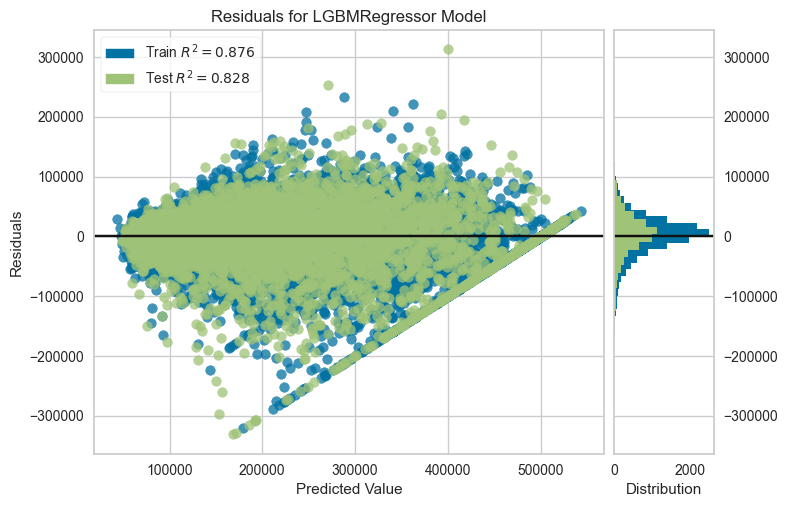

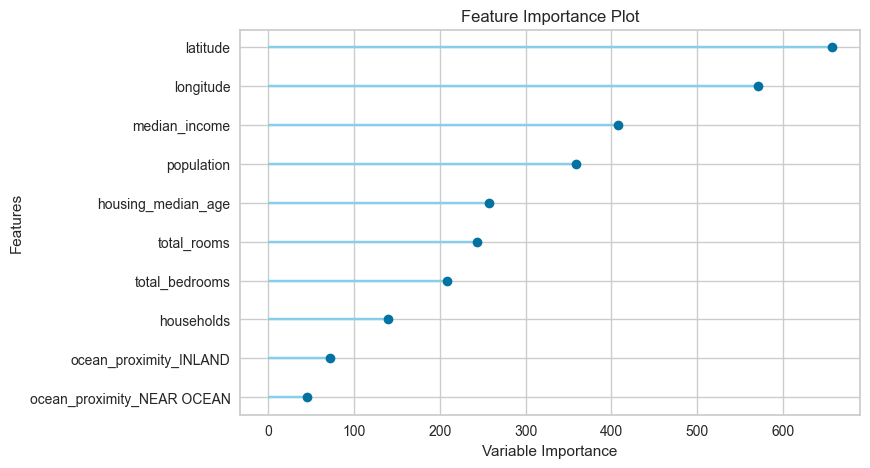

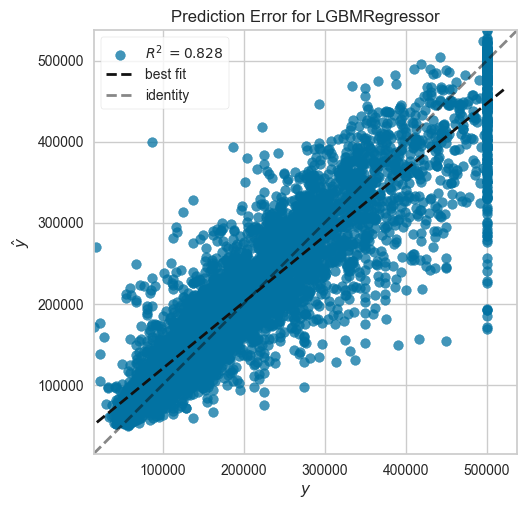

In [14]:
plot_model(best_model, plot="residuals")
plot_model(best_model, plot="feature")
plot_model(best_model, plot="error")

In [10]:
predictions = predict_model(best_model)
predictions.head()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,32058.9825,2251229569.4155,47447.1239,0.8285,0.2370,0.1822


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,prediction_label
20046,-119.010002,36.060001,25.0,1505.0,NaN,1392.0,359.0,1.6812,INLAND,47700.0,60486.998658
3024,-119.459999,35.139999,30.0,2943.0,NaN,1565.0,584.0,2.5313,INLAND,45800.0,71075.948897
15663,-122.440002,37.799999,52.0,3830.0,NaN,1310.0,963.0,3.4801,NEAR BAY,500001.0,471627.445913
20484,-118.720001,34.279999,17.0,3051.0,NaN,1705.0,495.0,5.7376,<1H OCEAN,218600.0,252857.680105
9814,-121.930000,36.619999,34.0,2351.0,NaN,1063.0,428.0,3.7250,NEAR OCEAN,278000.0,317440.811233


In [11]:
save_model(best_model, "housing_model")

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['longitude', 'latitude',
                                              'housing_median_age',
                                              'total_rooms', 'total_bedrooms',
                                              'population', 'households',
                                              'median_income'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=['ocean_proximity'],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('onehot_encoding',
                  TransformerWrapper(include=['ocean_proximity'],
                                     transformer=OneHotEncoder(cols=['ocean_proximity'],
                                                               handle_missing='return_nan',
              